In [280]:
import pandas as pd
import numpy as np
from faker import Faker
import random

In [281]:
fake = Faker()

In [282]:
occupations = [
  'Software Engineer', 'Teacher', 'Doctor', 'Nurse', 'Accountant', 'Salesperson',
    'Manager', 'Driver', 'Clerk', 'Electrician', 'Mechanic', 'Chef', 'Artist',
    'Scientist', 'Lawyer', 'Police Officer', 'Pharmacist', 'Consultant', 'Analyst', 'Farmer'
]

def generate_row_with_nulls():
  age = random.randint(15,60)
  income = random.randint(15000,100000)
  max_budget = min(income,200000)
  min_budget = 50000

  if max_budget < min_budget:
    budget = max_budget
  else:
    budget = random.randint(min_budget,max_budget)
  ph_no = fake.phone_number()if np.random.rand() > 0.1 else None
  mail_id = fake.email()if np.random.rand() > 0.1 else None
  rented_house = random.choice(['Yes','No'])
  insurance =  random.choice(['Yes','No'])
  occupation = random.choice(occupations)

  return [age,income,budget,ph_no,mail_id,rented_house,insurance,occupation]

num_rows = 10000

data = [generate_row_with_nulls() for _ in range(num_rows)]

columns = ['age','income','budget','ph_no','mail_id','rented_house','insurance','occupation']

df = pd.DataFrame(data,columns = columns)




In [283]:
df.shape

(10000, 8)

In [284]:
df.head()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
0,58,81604,78596,001-449-247-2053x56476,porterrichard@example.org,No,No,Nurse
1,31,49728,49728,634-748-4603x75016,angelawatson@example.com,Yes,No,Pharmacist
2,41,95020,59902,001-890-794-6370x384,acarter@example.org,No,No,Mechanic
3,24,42461,42461,+1-465-410-8008x444,zcombs@example.com,No,No,Software Engineer
4,39,78964,66365,+1-300-522-9675x14268,eric81@example.com,Yes,No,Teacher


In [285]:
df.tail()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
9995,32,68772,62833,None,mpeters@example.com,Yes,No,Doctor
9996,20,50959,50898,938.466.5893,williambutler@example.net,Yes,Yes,Doctor
9997,47,44863,44863,561-398-2397x64119,fbaird@example.com,Yes,No,Accountant
9998,25,63963,51741,001-277-380-1991x978,guzmanelizabeth@example.net,Yes,Yes,Driver
9999,44,43007,43007,001-851-613-2737,speterson@example.org,Yes,No,Artist


In [286]:
df.info

<bound method DataFrame.info of       age  income  budget                   ph_no  \
0      58   81604   78596  001-449-247-2053x56476   
1      31   49728   49728      634-748-4603x75016   
2      41   95020   59902    001-890-794-6370x384   
3      24   42461   42461     +1-465-410-8008x444   
4      39   78964   66365   +1-300-522-9675x14268   
...   ...     ...     ...                     ...   
9995   32   68772   62833                    None   
9996   20   50959   50898            938.466.5893   
9997   47   44863   44863      561-398-2397x64119   
9998   25   63963   51741    001-277-380-1991x978   
9999   44   43007   43007        001-851-613-2737   

                          mail_id rented_house insurance         occupation  
0       porterrichard@example.org           No        No              Nurse  
1        angelawatson@example.com          Yes        No         Pharmacist  
2             acarter@example.org           No        No           Mechanic  
3              zcom

In [287]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           10000 non-null  int64 
 1   income        10000 non-null  int64 
 2   budget        10000 non-null  int64 
 3   ph_no         9023 non-null   object
 4   mail_id       8975 non-null   object
 5   rented_house  10000 non-null  object
 6   insurance     10000 non-null  object
 7   occupation    10000 non-null  object
dtypes: int64(3), object(5)
memory usage: 625.1+ KB


In [288]:
df.describe()

,age,income,budget
count,10000.00000,10000.000000,10000.000000
mean,37.59390,57793.346600,50312.763900
std,13.16375,24628.746382,18265.782689
min,15.00000,15001.000000,15001.000000
25%,26.00000,36523.250000,36523.250000
50%,38.00000,57757.000000,51872.500000
75%,49.00000,79226.750000,61850.250000
max,60.00000,99985.000000,98896.000000


In [289]:
df.isna().sum()

age                0
income             0
budget             0
ph_no            977
mail_id         1025
rented_house       0
insurance          0
occupation         0
dtype: int64

In [290]:
df_cleaned = df.dropna(subset=['ph_no']).copy()

In [291]:
df_cleaned.shape

(9023, 8)

In [292]:
df_cleaned.isna().sum()

age               0
income            0
budget            0
ph_no             0
mail_id         920
rented_house      0
insurance         0
occupation        0
dtype: int64

In [293]:
df_cleaned['mail_id'] = df_cleaned['mail_id'].fillna('unknown')

In [294]:
df_cleaned.isna().sum()

age             0
income          0
budget          0
ph_no           0
mail_id         0
rented_house    0
insurance       0
occupation      0
dtype: int64

In [295]:
df_cleaned['mail_id'].value_counts()

mail_id
unknown                        920
vbrown@example.net               3
ianderson@example.net            3
slewis@example.com               3
pclark@example.net               3
                              ... 
nicholasschmidt@example.org      1
williambutler@example.net        1
fbaird@example.com               1
guzmanelizabeth@example.net      1
angelawatson@example.com         1
Name: count, Length: 7975, dtype: int64

In [296]:
df_cleaned.head()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
0,58,81604,78596,001-449-247-2053x56476,porterrichard@example.org,No,No,Nurse
1,31,49728,49728,634-748-4603x75016,angelawatson@example.com,Yes,No,Pharmacist
2,41,95020,59902,001-890-794-6370x384,acarter@example.org,No,No,Mechanic
3,24,42461,42461,+1-465-410-8008x444,zcombs@example.com,No,No,Software Engineer
4,39,78964,66365,+1-300-522-9675x14268,eric81@example.com,Yes,No,Teacher


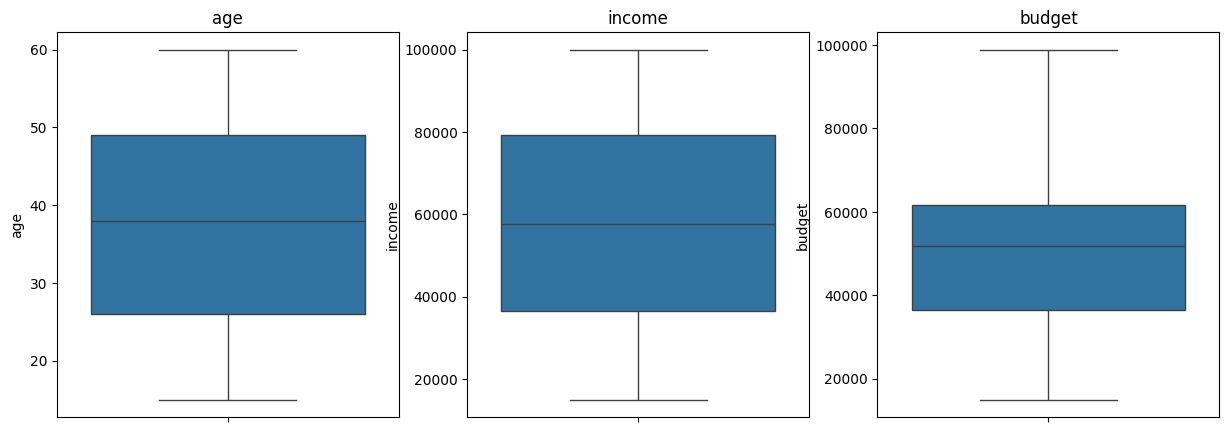

In [297]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y = df_cleaned['age'])
plt.title('age')

plt.subplot(1,3,2)
sns.boxplot(y = df_cleaned['income'])
plt.title('income')


plt.subplot(1,3,3)
sns.boxplot(y = df_cleaned['budget'])
plt.title('budget')

plt.show()


In [298]:
df_cleaned.describe(include='all')

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
count,9023.000000,9023.000000,9023.000000,9023,9023,9023,9023,9023
unique,NaN,NaN,NaN,9023,7975,2,2,20
top,NaN,NaN,NaN,001-851-613-2737,unknown,Yes,No,Farmer
freq,NaN,NaN,NaN,1,920,4513,4540,495
mean,37.573978,57704.400754,50248.562341,NaN,NaN,NaN,NaN,NaN
std,13.182628,24639.700008,18277.872172,NaN,NaN,NaN,NaN,NaN
min,15.000000,15001.000000,15001.000000,NaN,NaN,NaN,NaN,NaN
25%,26.000000,36472.500000,36472.500000,NaN,NaN,NaN,NaN,NaN
50%,38.000000,57557.000000,51833.000000,NaN,NaN,NaN,NaN,NaN
75%,49.000000,79144.000000,61752.500000,NaN,NaN,NaN,NaN,NaN


In [299]:
df_for_clustering = df_cleaned[['age', 'income', 'budget', 'rented_house', 'insurance', 'occupation']]

In [300]:
df_for_clustering.head()

,age,income,budget,rented_house,insurance,occupation
0,58,81604,78596,No,No,Nurse
1,31,49728,49728,Yes,No,Pharmacist
2,41,95020,59902,No,No,Mechanic
3,24,42461,42461,No,No,Software Engineer
4,39,78964,66365,Yes,No,Teacher


In [301]:
df_for_clustering.isna().sum()

age             0
income          0
budget          0
rented_house    0
insurance       0
occupation      0
dtype: int64

In [302]:
df_for_clustering.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9023 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           9023 non-null   int64 
 1   income        9023 non-null   int64 
 2   budget        9023 non-null   int64 
 3   rented_house  9023 non-null   object
 4   insurance     9023 non-null   object
 5   occupation    9023 non-null   object
dtypes: int64(3), object(3)
memory usage: 493.4+ KB


In [303]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, random_state = 42)
kmeans.fit(df_for_clustering[['age', 'income', 'budget']])
df_for_clustering['cluster'] = kmeans.labels_


C:\Users\DELL\AppData\Local\Temp\ipykernel_11384\1344914568.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_clustering['cluster'] = kmeans.labels_


In [304]:
type(df_for_clustering)

pandas.core.frame.DataFrame

In [305]:
df_cleaned_with_clusters = df_cleaned.copy()

In [306]:
df_cleaned_with_clusters["cluster_with_num_cols_only"] = kmeans.labels_

In [307]:
df_cleaned_with_clusters.head()  

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation,cluster_with_num_cols_only
0,58,81604,78596,001-449-247-2053x56476,porterrichard@example.org,No,No,Nurse,2
1,31,49728,49728,634-748-4603x75016,angelawatson@example.com,Yes,No,Pharmacist,0
2,41,95020,59902,001-890-794-6370x384,acarter@example.org,No,No,Mechanic,2
3,24,42461,42461,+1-465-410-8008x444,zcombs@example.com,No,No,Software Engineer,0
4,39,78964,66365,+1-300-522-9675x14268,eric81@example.com,Yes,No,Teacher,2


In [308]:
df_cleaned_with_clusters['cluster_with_num_cols_only'].value_counts()

cluster_with_num_cols_only
0    3204
2    3068
1    2751
Name: count, dtype: int64

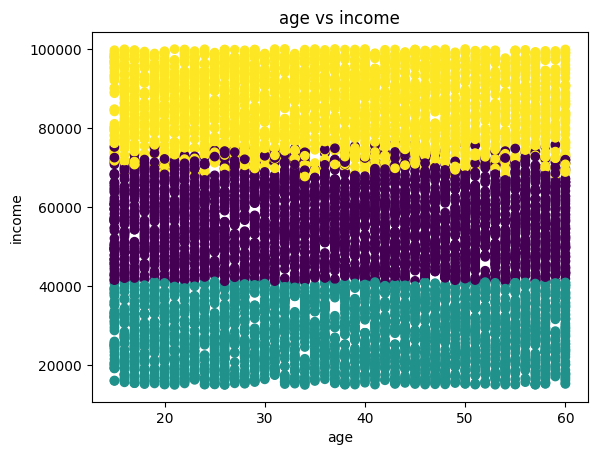

In [309]:
plt.scatter(df_cleaned_with_clusters['age'],df_cleaned_with_clusters['income'],c =df_cleaned_with_clusters['cluster_with_num_cols_only'],cmap = 'viridis')
plt.xlabel('age')
plt.ylabel('income')
plt.title('age vs income')
plt.show()

In [310]:
df_cleaned.head()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
0,58,81604,78596,001-449-247-2053x56476,porterrichard@example.org,No,No,Nurse
1,31,49728,49728,634-748-4603x75016,angelawatson@example.com,Yes,No,Pharmacist
2,41,95020,59902,001-890-794-6370x384,acarter@example.org,No,No,Mechanic
3,24,42461,42461,+1-465-410-8008x444,zcombs@example.com,No,No,Software Engineer
4,39,78964,66365,+1-300-522-9675x14268,eric81@example.com,Yes,No,Teacher


In [311]:
df_cleaned.shape

(9023, 8)

In [312]:
df_for_clustering.head(2)

,age,income,budget,rented_house,insurance,occupation,cluster
0,58,81604,78596,No,No,Nurse,2
1,31,49728,49728,Yes,No,Pharmacist,0


In [313]:
df_cleaned_with_clusters.head(2)

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation,cluster_with_num_cols_only
0,58,81604,78596,001-449-247-2053x56476,porterrichard@example.org,No,No,Nurse,2
1,31,49728,49728,634-748-4603x75016,angelawatson@example.com,Yes,No,Pharmacist,0


In [314]:
df_cleaned['mail_id'].value_counts()

mail_id
unknown                        920
vbrown@example.net               3
ianderson@example.net            3
slewis@example.com               3
pclark@example.net               3
                              ... 
nicholasschmidt@example.org      1
williambutler@example.net        1
fbaird@example.com               1
guzmanelizabeth@example.net      1
angelawatson@example.com         1
Name: count, Length: 7975, dtype: int64

In [315]:
df_cleaned_wo_duplicates = df_cleaned.drop_duplicates()

In [316]:
df_cleaned_wo_duplicates.shape

(9023, 8)

In [317]:
df_cleaned_wo_duplicates_ph_mail = df_cleaned.drop_duplicates(subset = ['ph_no','mail_id'])

In [318]:
df_cleaned_wo_duplicates.shape

(9023, 8)

In [319]:
df_cleaned['mail_id'].value_counts()

mail_id
unknown                        920
vbrown@example.net               3
ianderson@example.net            3
slewis@example.com               3
pclark@example.net               3
                              ... 
nicholasschmidt@example.org      1
williambutler@example.net        1
fbaird@example.com               1
guzmanelizabeth@example.net      1
angelawatson@example.com         1
Name: count, Length: 7975, dtype: int64

In [320]:
df_cleaned_wo_duplicates_mail = df_cleaned.drop_duplicates(subset=['mail_id'])

In [321]:
df_cleaned_wo_duplicates_mail.shape

(7975, 8)

In [322]:
df_for_clustering.head()

,age,income,budget,rented_house,insurance,occupation,cluster
0,58,81604,78596,No,No,Nurse,2
1,31,49728,49728,Yes,No,Pharmacist,0
2,41,95020,59902,No,No,Mechanic,2
3,24,42461,42461,No,No,Software Engineer,0
4,39,78964,66365,Yes,No,Teacher,2


In [323]:
df_for_clustering['rented_house'].value_counts()

rented_house
Yes    4513
No     4510
Name: count, dtype: int64

In [324]:
df_for_clustering['insurance'].value_counts()

insurance
No     4540
Yes    4483
Name: count, dtype: int64

In [325]:
df_for_clustering['occupation'].nunique()

20

In [326]:
df_for_clustering['occupation'].value_counts()

occupation
Farmer               495
Teacher              473
Driver               471
Chef                 470
Software Engineer    467
Accountant           465
Pharmacist           458
Salesperson          457
Lawyer               455
Consultant           454
Scientist            453
Police Officer       446
Nurse                443
Clerk                439
Electrician          436
Mechanic             434
Doctor               434
Analyst              431
Manager              421
Artist               421
Name: count, dtype: int64

In [327]:
df_cleaned_with_clusters

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation,cluster_with_num_cols_only
0,58,81604,78596,001-449-247-2053x56476,porterrichard@example.org,No,No,Nurse,2
1,31,49728,49728,634-748-4603x75016,angelawatson@example.com,Yes,No,Pharmacist,0
2,41,95020,59902,001-890-794-6370x384,acarter@example.org,No,No,Mechanic,2
3,24,42461,42461,+1-465-410-8008x444,zcombs@example.com,No,No,Software Engineer,0
4,39,78964,66365,+1-300-522-9675x14268,eric81@example.com,Yes,No,Teacher,2
...,...,...,...,...,...,...,...,...,...
9994,40,67802,59457,516.886.8710x451,nicholasschmidt@example.org,Yes,No,Electrician,0
9996,20,50959,50898,938.466.5893,williambutler@example.net,Yes,Yes,Doctor,0
9997,47,44863,44863,561-398-2397x64119,fbaird@example.com,Yes,No,Accountant,0
9998,25,63963,51741,001-277-380-1991x978,guzmanelizabeth@example.net,Yes,Yes,Driver,0


In [328]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_for_clustering['rented_house_label'] = label_encoder.fit_transform(df_for_clustering['rented_house'])

In [329]:
df_for_clustering

,age,income,budget,rented_house,insurance,occupation,cluster,rented_house_label
0,58,81604,78596,No,No,Nurse,2,0
1,31,49728,49728,Yes,No,Pharmacist,0,1
2,41,95020,59902,No,No,Mechanic,2,0
3,24,42461,42461,No,No,Software Engineer,0,0
4,39,78964,66365,Yes,No,Teacher,2,1
...,...,...,...,...,...,...,...,...
9994,40,67802,59457,Yes,No,Electrician,0,1
9996,20,50959,50898,Yes,Yes,Doctor,0,1
9997,47,44863,44863,Yes,No,Accountant,0,1
9998,25,63963,51741,Yes,Yes,Driver,0,1


In [330]:
df_for_clustering['insurance_label'] = label_encoder.fit_transform(df_for_clustering['insurance'])

In [331]:
df_for_clustering

,age,income,budget,rented_house,insurance,occupation,cluster,rented_house_label,insurance_label
0,58,81604,78596,No,No,Nurse,2,0,0
1,31,49728,49728,Yes,No,Pharmacist,0,1,0
2,41,95020,59902,No,No,Mechanic,2,0,0
3,24,42461,42461,No,No,Software Engineer,0,0,0
4,39,78964,66365,Yes,No,Teacher,2,1,0
...,...,...,...,...,...,...,...,...,...
9994,40,67802,59457,Yes,No,Electrician,0,1,0
9996,20,50959,50898,Yes,Yes,Doctor,0,1,1
9997,47,44863,44863,Yes,No,Accountant,0,1,0
9998,25,63963,51741,Yes,Yes,Driver,0,1,1


In [332]:
df_for_clustering['occupation_label'] = label_encoder.fit_transform(df_for_clustering['occupation'])

In [333]:
df_for_clustering.head()

,age,income,budget,rented_house,insurance,occupation,cluster,rented_house_label,insurance_label,occupation_label
0,58,81604,78596,No,No,Nurse,2,0,0,13
1,31,49728,49728,Yes,No,Pharmacist,0,1,0,14
2,41,95020,59902,No,No,Mechanic,2,0,0,12
3,24,42461,42461,No,No,Software Engineer,0,0,0,18
4,39,78964,66365,Yes,No,Teacher,2,1,0,19


In [334]:
df_for_clustering.columns

Index(['age', 'income', 'budget', 'rented_house', 'insurance', 'occupation',
       'cluster', 'rented_house_label', 'insurance_label', 'occupation_label'],
      dtype='object')

In [335]:
df_with_label_encoded = df_for_clustering[['age','income','budget','rented_house_label','insurance_label','occupation_label']]

In [336]:
df_with_label_encoded.head()

,age,income,budget,rented_house_label,insurance_label,occupation_label
0,58,81604,78596,0,0,13
1,31,49728,49728,1,0,14
2,41,95020,59902,0,0,12
3,24,42461,42461,0,0,18
4,39,78964,66365,1,0,19


In [337]:
df_with_label_encoded.isna().sum()

age                   0
income                0
budget                0
rented_house_label    0
insurance_label       0
occupation_label      0
dtype: int64

In [338]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, random_state = 42)

kmeans.fit(df_with_label_encoded)

df_cleaned_with_clusters['cluster_with_cat_cols_only'] = kmeans.labels_


In [339]:
df_cleaned_with_clusters

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation,cluster_with_num_cols_only,cluster_with_cat_cols_only
0,58,81604,78596,001-449-247-2053x56476,porterrichard@example.org,No,No,Nurse,2,2
1,31,49728,49728,634-748-4603x75016,angelawatson@example.com,Yes,No,Pharmacist,0,0
2,41,95020,59902,001-890-794-6370x384,acarter@example.org,No,No,Mechanic,2,2
3,24,42461,42461,+1-465-410-8008x444,zcombs@example.com,No,No,Software Engineer,0,0
4,39,78964,66365,+1-300-522-9675x14268,eric81@example.com,Yes,No,Teacher,2,2
...,...,...,...,...,...,...,...,...,...,...
9994,40,67802,59457,516.886.8710x451,nicholasschmidt@example.org,Yes,No,Electrician,0,0
9996,20,50959,50898,938.466.5893,williambutler@example.net,Yes,Yes,Doctor,0,0
9997,47,44863,44863,561-398-2397x64119,fbaird@example.com,Yes,No,Accountant,0,0
9998,25,63963,51741,001-277-380-1991x978,guzmanelizabeth@example.net,Yes,Yes,Driver,0,0


In [340]:
df_cleaned_with_clusters.head(2)

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation,cluster_with_num_cols_only,cluster_with_cat_cols_only
0,58,81604,78596,001-449-247-2053x56476,porterrichard@example.org,No,No,Nurse,2,2
1,31,49728,49728,634-748-4603x75016,angelawatson@example.com,Yes,No,Pharmacist,0,0


In [341]:
df_cleaned_with_clusters['cluster_with_num_cols_only'].value_counts()

cluster_with_num_cols_only
0    3204
2    3068
1    2751
Name: count, dtype: int64

In [342]:
df_cleaned_with_clusters['cluster_with_cat_cols_only'].value_counts()

cluster_with_cat_cols_only
0    3202
2    3073
1    2748
Name: count, dtype: int64

In [343]:
df_with_label_encoded.head()

,age,income,budget,rented_house_label,insurance_label,occupation_label
0,58,81604,78596,0,0,13
1,31,49728,49728,1,0,14
2,41,95020,59902,0,0,12
3,24,42461,42461,0,0,18
4,39,78964,66365,1,0,19


In [346]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

x = df_with_label_encoded

wcss = []
silhouette_scores = []

K = range(2,11)
print("printing k values after range function")
print(K)

for k in K:
  print(k)
  kmeans = KMeans(n_clusters = k, random_state = 42)
  labels = kmeans.fit_predict(x)

  wcss.append(kmeans.inertia_)
  print("wcss score is ")
  print(wcss)
  silhouette_scores.append(silhouette_score(x,labels))
  print("silhouette scores is")
  print(silhouette_scores)


printing k values after range function
range(2, 11)
2
wcss score is 
[2526137976872.1904]
silhouette scores is
[0.5783593747548281]
3
wcss score is 
[2526137976872.1904, 1264236349879.873]
silhouette scores is
[0.5783593747548281, 0.5342740595044498]
4
wcss score is 
[2526137976872.1904, 1264236349879.873, 858829878381.2334]
silhouette scores is
[0.5783593747548281, 0.5342740595044498, 0.48910438854067806]
5
wcss score is 
[2526137976872.1904, 1264236349879.873, 858829878381.2334, 623372643668.5071]
silhouette scores is
[0.5783593747548281, 0.5342740595044498, 0.48910438854067806, 0.4749534197964524]
6
wcss score is 
[2526137976872.1904, 1264236349879.873, 858829878381.2334, 623372643668.5071, 465524737829.85376]
silhouette scores is
[0.5783593747548281, 0.5342740595044498, 0.48910438854067806, 0.4749534197964524, 0.4786056321605552]
7
wcss score is 
[2526137976872.1904, 1264236349879.873, 858829878381.2334, 623372643668.5071, 465524737829.85376, 381510940728.97705]
silhouette scores i

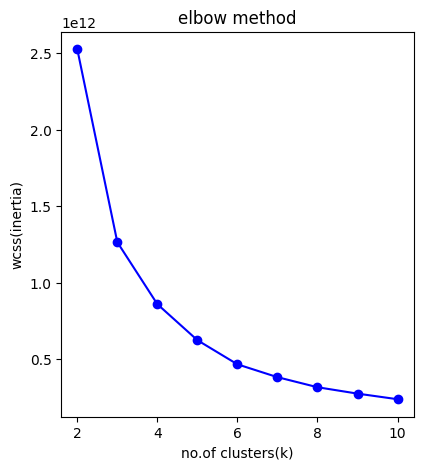

In [356]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("elbow method")
plt.plot(K, wcss, 'bo-')
plt.xlabel('no.of clusters(k)')
plt.ylabel('wcss(inertia)')
plt.show()


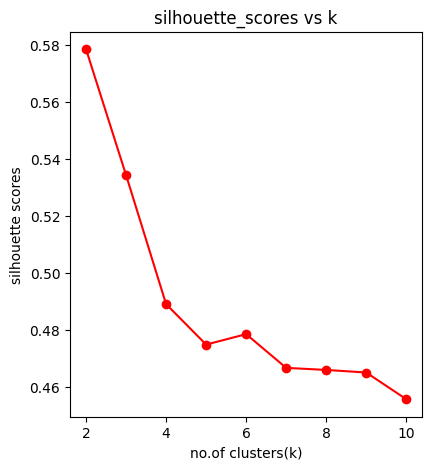

In [359]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,2)
plt.title("silhouette_scores vs k")
plt.plot(K,silhouette_scores,'ro-')

plt.xlabel('no.of clusters(k)')
plt.ylabel('silhouette scores')
plt.show()